# Problem: Adversarial Attacks

## **<span style="color:orange">Importing Libraries, Declaring Constants, Setting Seed & DEVICE </span>**

To load the downloaded weights, you'll need the `pytorch_cifar_models` package. Please ensure that you place the downloaded `pytorch_cifar_models` folder (from elearn) in the same directory as your code.

Alternatively, you can clone the repository directly by running the following command in your terminal:
```bash
!git clone https://github.com/chenyaofo/pytorch-cifar-models.git


In [1]:
import sys
sys.path.append("../pytorch-cifar-models")

import pytorch_cifar_models as pcm

Library

In [2]:
import os
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
import random

Set DEVICE

In [3]:
DEVICE = "cpu"
if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"

print(f"Using device: {DEVICE}")

Using device: cuda


Constants

In [4]:
BATCH_SIZE = 4

In [5]:
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
CIFAR10_DIR = "../data/Q2/cifar10_correct_samples"
RESENET20_WEIGHTS = "../models/cifar10_resnet20-4118986f.pt"

## **<span style="color:orange">Load Model & Data</span>**

Load model

In [7]:
model = pcm.cifar10_resnet20(pretrained=False)

In [8]:
state_dict = torch.load(RESENET20_WEIGHTS, map_location=DEVICE)
model.load_state_dict(state_dict)
model.eval()
model.to(DEVICE)

CifarResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

Load image

In [9]:
class CIFARCustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.files = [
            f for f in os.listdir(root_dir)
            if f.endswith(".png")
        ]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]
        path = os.path.join(self.root_dir, filename)

        # load image
        image = Image.open(path).convert("RGB")

        # parse label from filename: "..._true3.png"
        label_str = filename.split("_true")[1].split(".png")[0]
        label = int(label_str)

        if self.transform:
            image = self.transform(image)

        return image, label

In [10]:
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.flatten().tolist(),
                        std=std.flatten().tolist())
])

dataset = CIFARCustomDataset(
    root_dir=CIFAR10_DIR,
    transform=transform
)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
print(f"Number of images: {len(dataset)}")
print(f"Number of batches: {len(dataloader)}")

Number of images: 25
Number of batches: 7


Check Model and Dataset Load

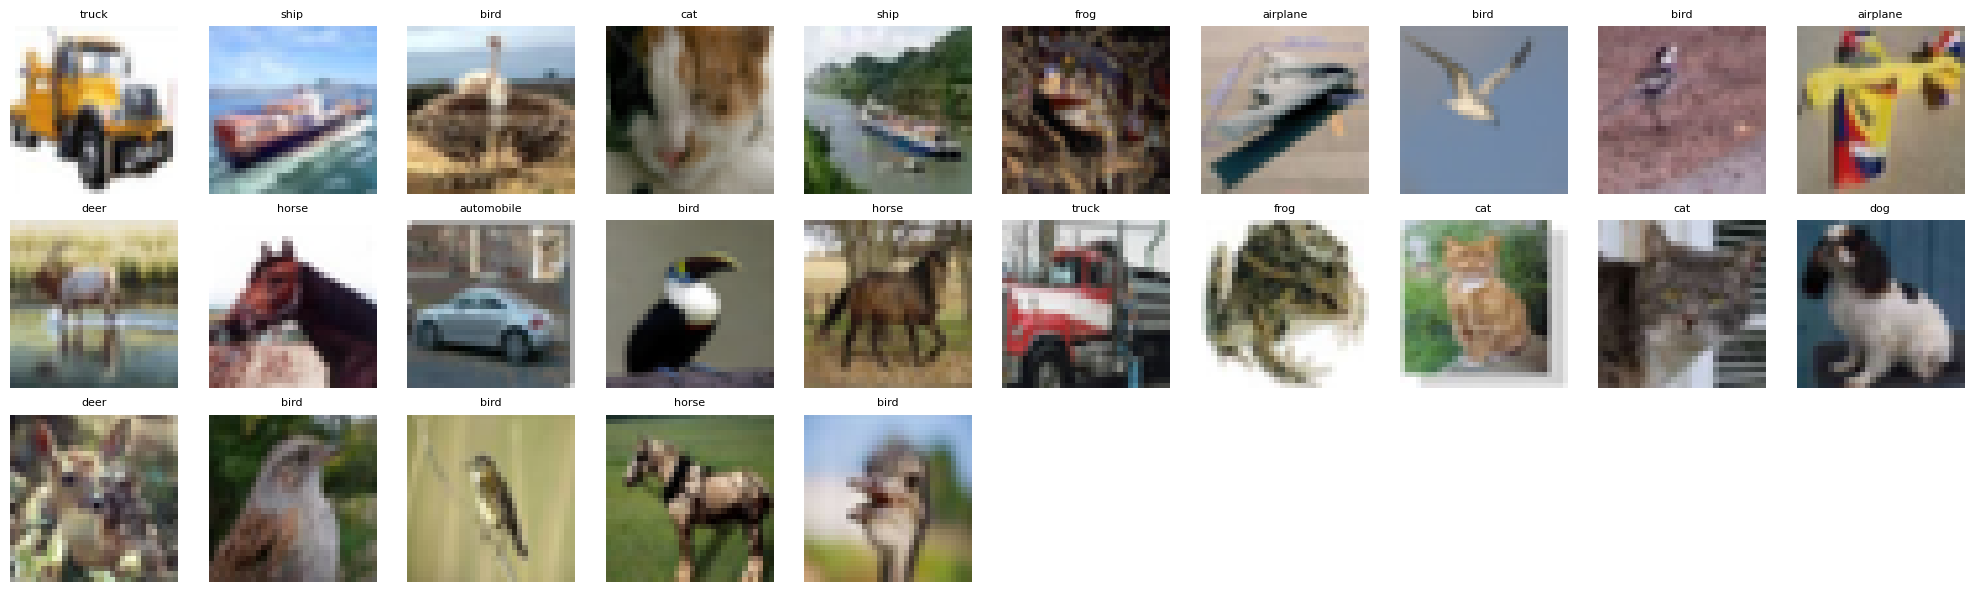

In [12]:
num_images = len(dataset)
cols = 10
rows = 3

fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
axes = np.array(axes).reshape(-1)

for i in range(num_images):
    img, true_lbl = dataset[i]
    img = img * std + mean
    img = torch.clamp(img, 0, 1)

    axes[i].imshow(img.permute(1, 2, 0).numpy())
    axes[i].set_title(f"{CIFAR10_CLASSES[true_lbl]}", fontsize=8)
    axes[i].axis("off")

for j in range(num_images, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [13]:
def evaluate(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(data_loader):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    return accuracy

In [14]:
accuracy_clean_data = evaluate(model, dataloader)
print(f"Accuracy of the model on the {len(dataset)} clean images: {accuracy_clean_data:.4f}")

100%|██████████| 7/7 [00:00<00:00, 27.75it/s]

Accuracy of the model on the 25 clean images: 1.0000


## **<span style="color:orange">Attacks</span>**

In [15]:
def fgsm_attack(model, images, labels, epsilon):
    if epsilon == 0:
        return images
    
    images = images.clone().detach().to(DEVICE)
    labels = labels.to(DEVICE)
    images.requires_grad = True
    
    outputs = model(images)
    loss = nn.CrossEntropyLoss()(outputs, labels)
    
    model.zero_grad()
    loss.backward()
    
    data_grad = images.grad.data
    sign_data_grad = data_grad.sign()
    
    perturbed_image = images + epsilon * sign_data_grad
    return perturbed_image

In [16]:
def pgd_attack(model, images, labels, epsilon, alpha, steps):
    if epsilon == 0:
        return images
        
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)
    
    original_images = images.clone().detach()
    adv_images = images.clone().detach()
    
    adv_images = adv_images + torch.empty_like(adv_images).uniform_(-epsilon, epsilon)
    
    for _ in range(steps):
        adv_images.requires_grad = True
        
        outputs = model(adv_images)
        loss = nn.CrossEntropyLoss()(outputs, labels)
        
        model.zero_grad()
        loss.backward()
        
        grad = adv_images.grad.data
        adv_images = adv_images.detach() + alpha * grad.sign()
        
        delta = torch.clamp(adv_images - original_images, min=-epsilon, max=epsilon)
        adv_images = original_images + delta
        
    return adv_images

In [17]:
def display_adversarial_examples(orig_images, adv_images, labels, preds, title=''):
    mean_t = mean.to(DEVICE)
    std_t = std.to(DEVICE)
    
    num_display = min(4, orig_images.size(0))
    fig, axes = plt.subplots(num_display, 3, figsize=(9, 3 * num_display))
    
    for i in range(num_display):
        o_img = orig_images[i] * std_t + mean_t
        a_img = adv_images[i] * std_t + mean_t
        
        noise = a_img - o_img
        noise = (noise - noise.min()) / (noise.max() - noise.min() + 1e-8)
        
        o_img = torch.clamp(o_img, 0, 1).cpu().permute(1, 2, 0).numpy()
        a_img = torch.clamp(a_img, 0, 1).cpu().permute(1, 2, 0).numpy()
        noise = noise.cpu().permute(1, 2, 0).numpy()
        
        true_lbl = CIFAR10_CLASSES[labels[i].item()]
        pred_lbl = CIFAR10_CLASSES[preds[i].item()]
        
        axes[i, 0].imshow(o_img)
        axes[i, 0].set_title(f'Original\nTrue: {true_lbl}', fontsize=10)
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(noise)
        axes[i, 1].set_title('Perturbation (Noise)', fontsize=10)
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(a_img)
        
        color = 'red' if true_lbl != pred_lbl else 'green'
        axes[i, 2].set_title(f'Adversarial\nPred: {pred_lbl}', fontsize=10, color=color)
        axes[i, 2].axis('off')
        
    plt.suptitle(f'{title} Attack Examples', fontsize=14)
    plt.tight_layout()
    plt.show()

100%|██████████| 7/7 [00:00<00:00, 31.25it/s]


Accuracy after FGSM: 28.00%


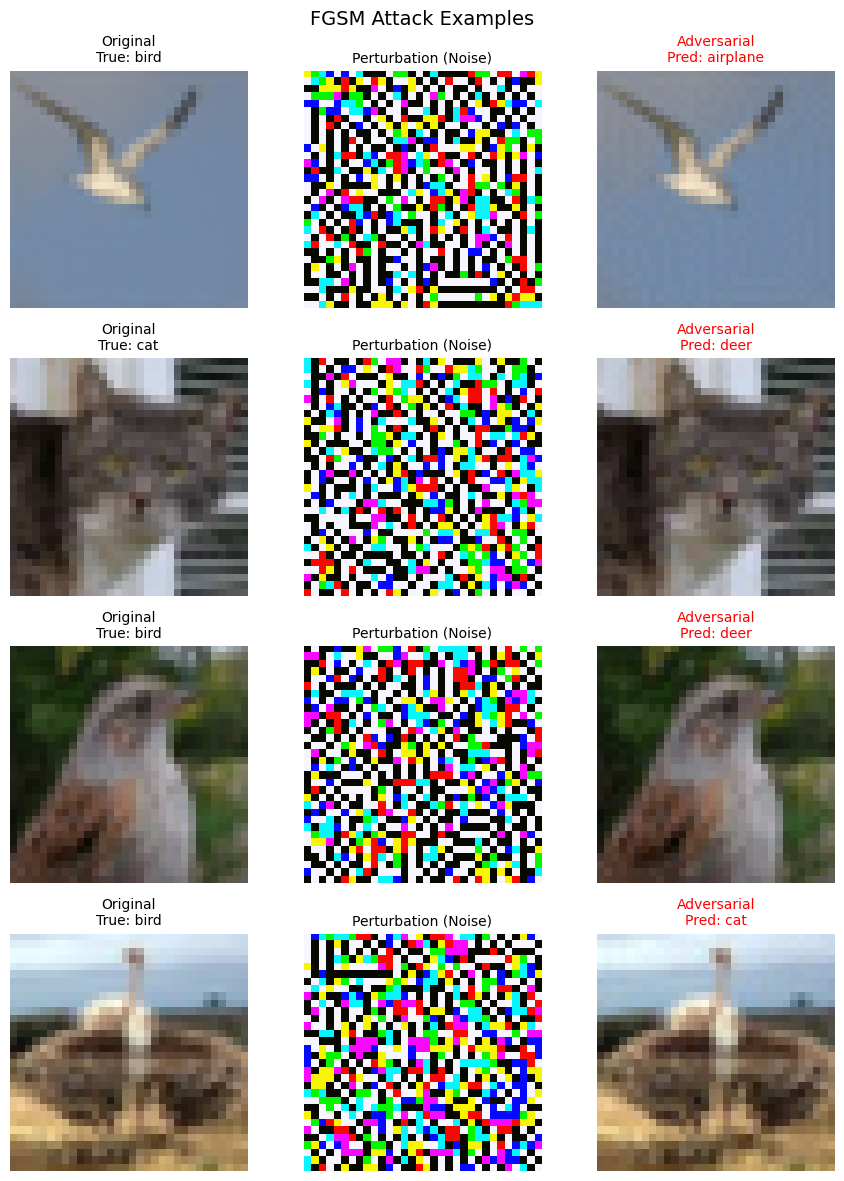

In [18]:
model.eval()

correct, total = 0, 0
all_orig, all_adv, all_labels, all_preds = [], [], [], []

epsilon = 0.03

for images, labels in tqdm(dataloader):
    images, labels = images.to(DEVICE), labels.to(DEVICE)

    adv_images = fgsm_attack(model, images, labels, epsilon)

    with torch.no_grad():
        preds = model(adv_images).argmax(1)

    total += labels.size(0)
    correct += (preds == labels).sum().item()

    wrong = (preds != labels).nonzero(as_tuple=True)[0]
    if len(wrong) > 0:
        all_orig.extend(images[wrong].detach())
        all_adv.extend(adv_images[wrong].detach())
        all_labels.extend(labels[wrong].detach())
        all_preds.extend(preds[wrong].detach())

acc = correct / total
print(f'Accuracy after FGSM: {acc * 100:.2f}%')


indices = random.sample(range(len(all_orig)), 4)

sel_orig  = torch.stack([all_orig[i]  for i in indices])
sel_adv   = torch.stack([all_adv[i]   for i in indices])
sel_label = torch.tensor([all_labels[i] for i in indices])
sel_pred  = torch.tensor([all_preds[i]  for i in indices])

display_adversarial_examples(sel_orig, sel_adv, sel_label, sel_pred, title='FGSM')

100%|██████████| 7/7 [00:00<00:00,  7.15it/s]


Accuracy after PGD: 4.00%


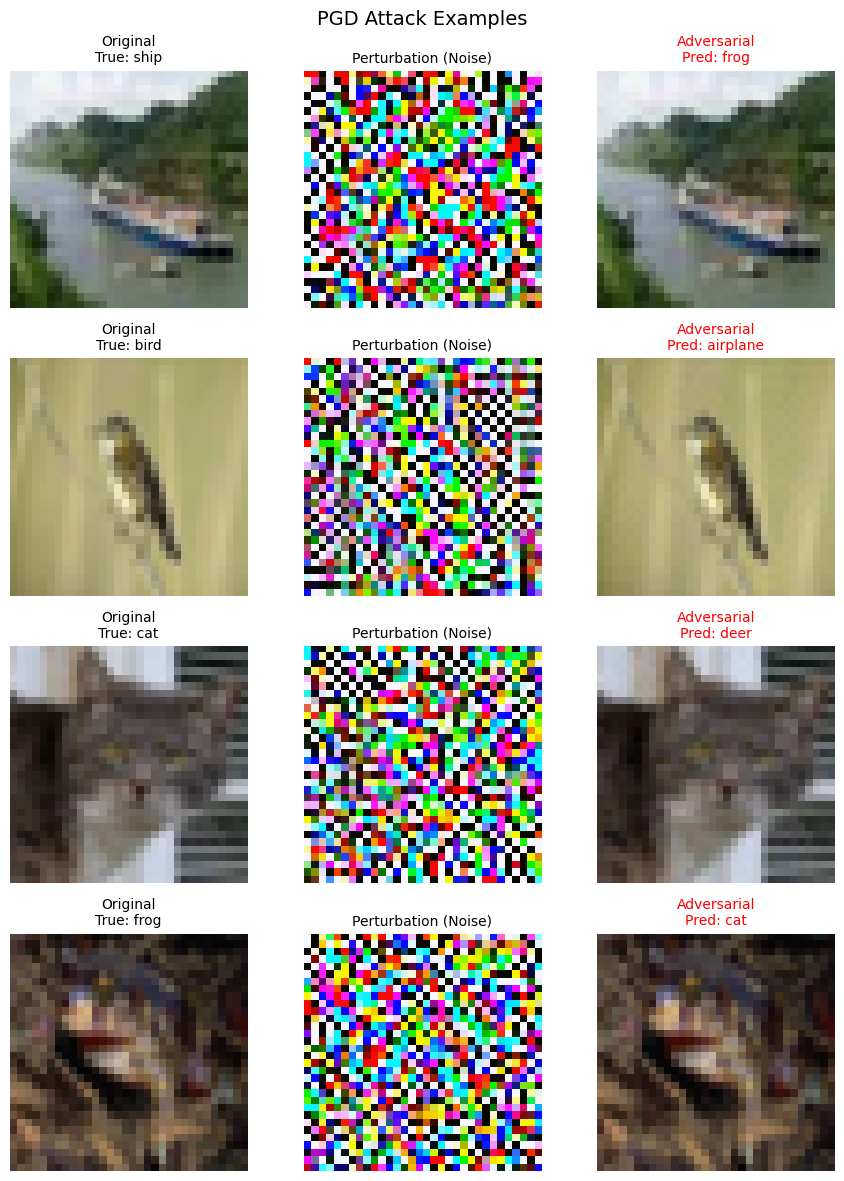

In [19]:
model.eval()

correct, total = 0, 0
all_orig, all_adv, all_labels, all_preds = [], [], [], []

epsilon = 0.03
alpha=0.005
steps = 20

for images, labels in tqdm(dataloader):
    images, labels = images.to(DEVICE), labels.to(DEVICE)

    adv_images = pgd_attack(model, images, labels, epsilon, alpha, steps)

    with torch.no_grad():
        preds = model(adv_images).argmax(1)

    total += labels.size(0)
    correct += (preds == labels).sum().item()

    wrong = (preds != labels).nonzero(as_tuple=True)[0]
    if len(wrong) > 0:
        all_orig.extend(images[wrong].detach())
        all_adv.extend(adv_images[wrong].detach())
        all_labels.extend(labels[wrong].detach())
        all_preds.extend(preds[wrong].detach())

acc = correct / total
print(f'Accuracy after PGD: {acc * 100:.2f}%')


indices = random.sample(range(len(all_orig)), 4)

sel_orig  = torch.stack([all_orig[i]  for i in indices])
sel_adv   = torch.stack([all_adv[i]   for i in indices])
sel_label = torch.tensor([all_labels[i] for i in indices])
sel_pred  = torch.tensor([all_preds[i]  for i in indices])

display_adversarial_examples(sel_orig, sel_adv, sel_label, sel_pred, title='PGD')